Import Libraries

In [1]:
import pandas as pd

Load your dataset excel / csv

In [2]:
df=pd.read_csv("Telecom_Network_Data.csv")

Basic overview

In [3]:
df.head()

,timestamp,tower_id,users_connected,download_speed,upload_speed,latency,weather,congestion
0,01-01-2025 00:00,1,152,80.67,9.99,158.14,Clear,0
1,01-01-2025 01:00,1,171,19.82,3.85,174.57,Clear,0
2,01-01-2025 02:00,1,713,66.83,3.76,147.18,Snow,0
3,01-01-2025 03:00,1,435,22.27,9.99,67.81,Clear,0
4,01-01-2025 04:00,1,797,7.19,26.71,85.97,Clear,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3605 entries, 0 to 3604
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        3605 non-null   str    
 1   tower_id         3605 non-null   int64  
 2   users_connected  3605 non-null   int64  
 3   download_speed   3605 non-null   float64
 4   upload_speed     3605 non-null   float64
 5   latency          3605 non-null   float64
 6   weather          3605 non-null   str    
 7   congestion       3605 non-null   int64  
dtypes: float64(3), int64(3), str(2)
memory usage: 225.4 KB


In [5]:
df.describe()

,tower_id,users_connected,download_speed,upload_speed,latency,congestion
count,3605.00000,3605.000000,3605.000000,3605.000000,3605.000000,3605.000000
mean,3.00000,531.091817,52.087623,25.167176,105.100416,0.056311
std,1.41441,275.722937,27.343367,13.995882,54.884386,0.230553
min,1.00000,50.000000,5.000000,1.050000,10.030000,0.000000
25%,2.00000,294.000000,28.480000,13.380000,58.080000,0.000000
50%,3.00000,538.000000,52.510000,25.100000,105.180000,0.000000
75%,4.00000,765.000000,75.250000,37.010000,153.870000,0.000000
max,5.00000,999.000000,99.990000,49.990000,199.950000,1.000000


Network Performance Distribution

In [6]:
import seaborn as sns

In [7]:
import matplotlib.pyplot as plt

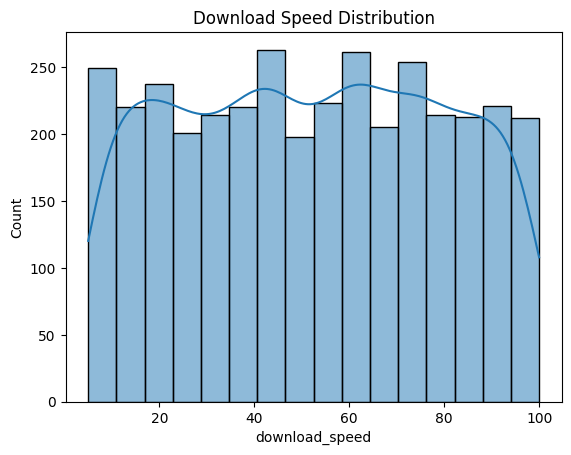

In [8]:
sns.histplot(df['download_speed'], kde = True)
plt.title("Download Speed Distribution")
plt.show()

Download speeds are fairly evenly distributed across the range, indicating consistent network performance without heavy skew toward low or high speeds.
The smooth KDE curve suggests stable variability, with most users experiencing moderate-to-high speeds rather than extreme fluctuations.

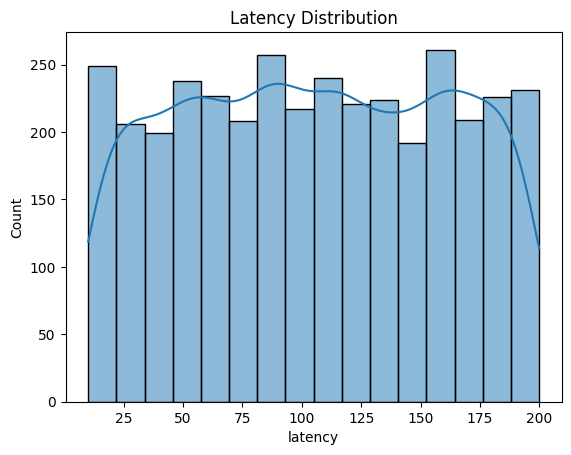

In [9]:
sns.histplot(df['latency'], kde = True)
plt.title("Latency Distribution")
plt.show()

Latency values are widely spread with a relatively uniform distribution, indicating inconsistent response times across the network.
The absence of a strong peak suggests users experience varied latency levels, pointing to potential instability in network performance.

Congestion Impact(over download speed)

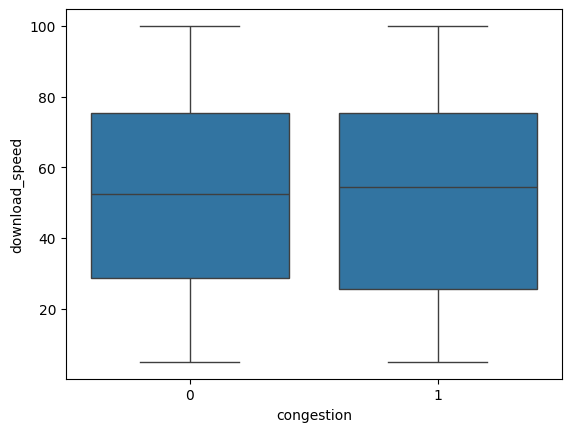

In [10]:
sns.boxplot(x='congestion',y='download_speed',data = df)
plt.show()

Congestion shows negligible impact on download speed, indicating stable network performance across conditions.

Congestion Impact(over latency)

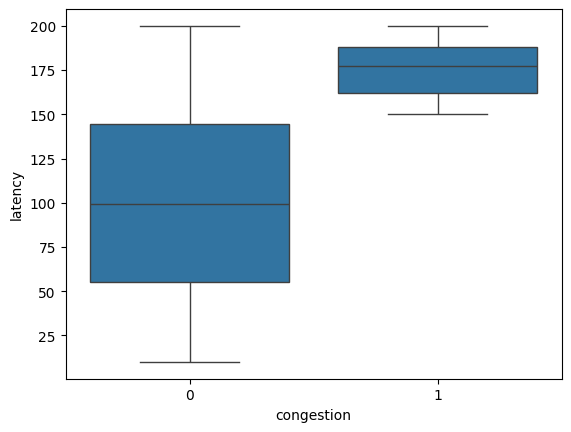

In [11]:
sns.boxplot(x='congestion', y='latency', data=df)
plt.show()

Latency is significantly higher under congestion, indicating a clear negative impact on network responsiveness.


Weather Impact (over download speed)

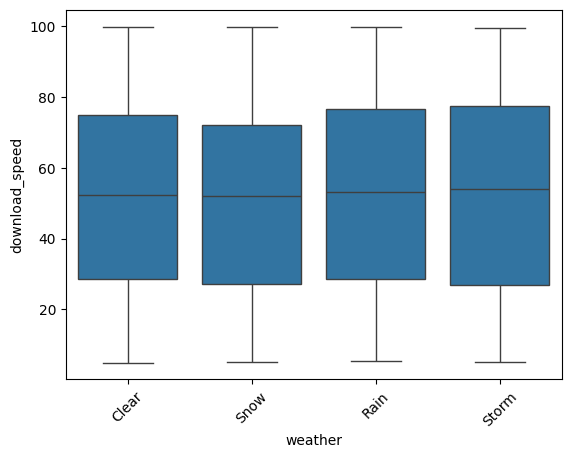

In [12]:
sns.boxplot(x='weather', y='download_speed', data=df)
plt.xticks(rotation=45)
plt.show()

Download speeds remain largely consistent across weather conditions, indicating minimal impact of weather on network performance.


Weather_Impact(over latency)

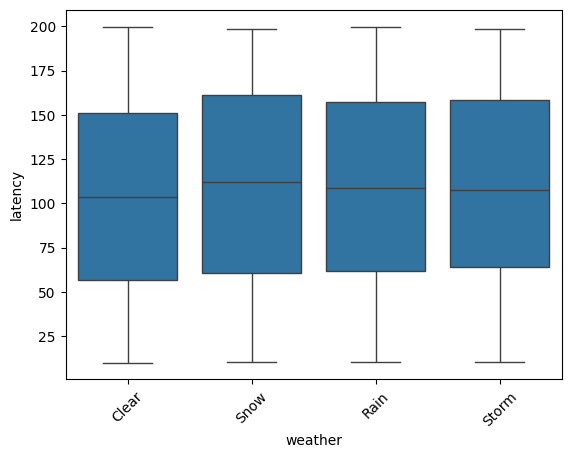

In [13]:
sns.boxplot(x='weather', y='latency', data=df)
plt.xticks(rotation=45)
plt.show()

Latency distributions are broadly similar across all weather types, suggesting weather has minimal impact on latency in this dataset.

Correlation Analysis

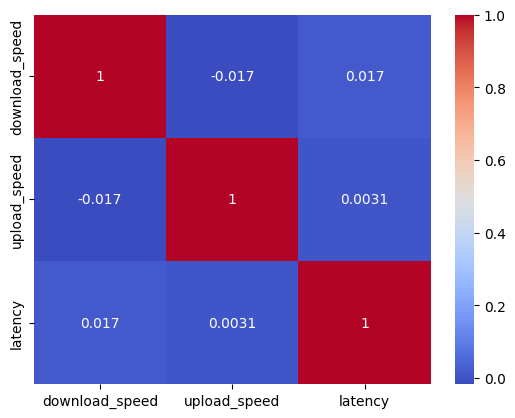

In [14]:
corr = df[['download_speed','upload_speed','latency']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


Download speed, upload speed, and latency show near-zero correlations, indicating they are largely independent in this dataset.


Outlier Detection

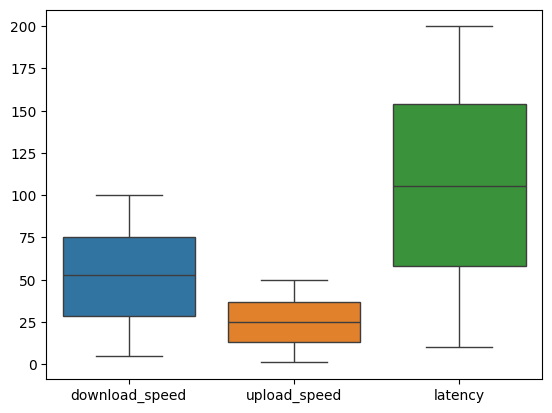

In [15]:
sns.boxplot(data=df[['download_speed','upload_speed','latency']])
plt.show()

All three metrics show wide spreads but no extreme outliers, with latency exhibiting the highest variability.


<Axes: xlabel='congestion', ylabel='latency'>

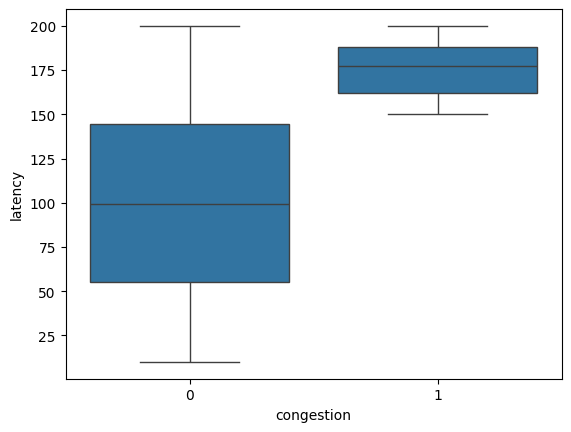

In [16]:
sns.boxplot(x='congestion', y='latency', data=df)

Latency is significantly higher and more consistent when congestion is present compared to when it is absent.
